In [7]:
# --- Бібліотеки для даної роботи ---
try:
    import matplotlib, matplotlib_venn
    print("Бібліотеки вже встановлені. Пропускаємо інсталяцію.")
except ImportError:
    print("Встановлюємо бібліотеки...")
    %pip install matplotlib matplotlib_venn

Бібліотеки вже встановлені. Пропускаємо інсталяцію.


## Задача 1. Аналітика музичного сервісу

**Умова:**

Ви працюєте аналітиком у музичному стрімінговому сервісі. У вас є дані про вподобання користувачів за останній місяць у вигляді ID клієнтів. Маркетинговий відділ хоче зрозуміти перетин аудиторій для планування рекламних кампаній.

Дано три множини користувачів:

- `rock_fans` — слухали рок: `{101, 102, 103, 105, 107, 109, 110, 112, 115, 118}`
- `pop_fans` — слухали поп: `{102, 104, 105, 106, 108, 110, 111, 113, 115, 117}`
- `jazz_fans` — слухали джаз: `{103, 105, 108, 110, 112, 114, 115, 116, 119, 120}`

Використовуючи можливості Python для роботи з множинами (`set`), напишіть програму та виконайте наступні кроки:

1. Визначте загальне охоплення: скільки **унікальних** користувачів слухали хоча б один із цих жанрів?
2. Знайдіть "всеїдних меломанів" — користувачів, які слухали **всі три** жанри. Виведіть їхні ID та кількість.
3. Знайдіть цільову аудиторію для нішевої реклами: "чисті рокери" — ті, хто слухав рок, але **НЕ** слухав ні поп, ні джаз.
4. Знайдіть користувачів, які слухали **рівно два** жанри (будь-яку пару, але не всі три).
5. Побудуйте візуалізацію перетинів (діаграму Венна) за допомогою бібліотеки `matplotlib_venn`.

Технічний вивід:
--- 1. Загальне охоплення ---
Кількість унікальних користувачів: 20
{101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120}


--- 2. Всеїдні меломани ---
Кількість: 3
ID користувачів: {105, 115, 110}
{105, 115, 110}


--- 3. Чисті рокери ---
Список ID: {101, 107, 109, 118}
{101, 107, 109, 118}


--- 4. Користувачі, що слухали рівно два жанри ---
Кількість: 4
Список ID: {112, 108, 102, 103}
{112, 108, 102, 103}


Красивий Вивід:


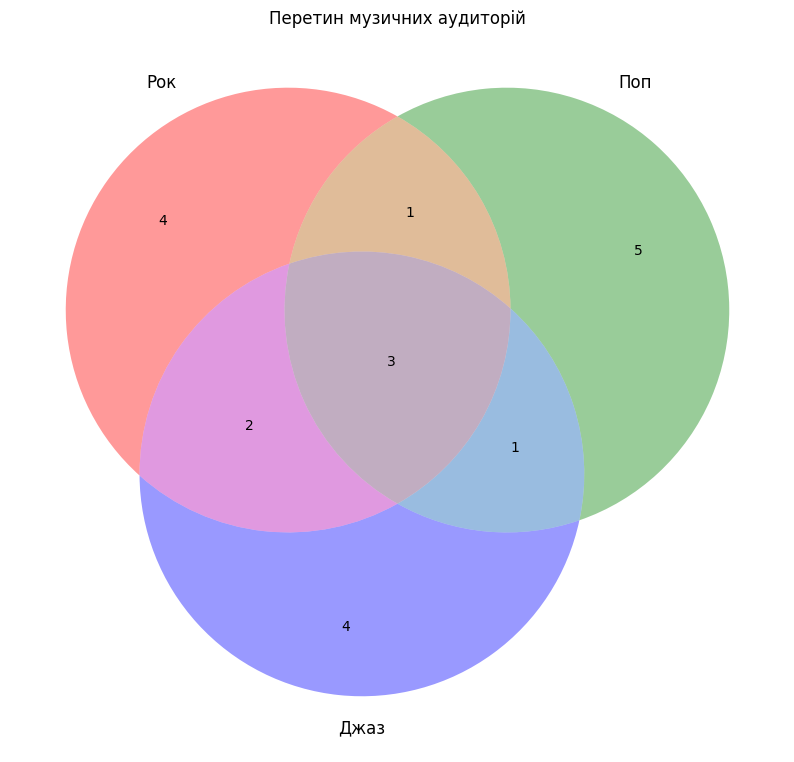

In [8]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

rock_fans = {101, 102, 103, 105, 107, 109, 110, 112, 115, 118}
pop_fans = {102, 104, 105, 106, 108, 110, 111, 113, 115, 117}
jazz_fans = {103, 105, 108, 110, 112, 114, 115, 116, 119, 120}

total_users = rock_fans.union(pop_fans, jazz_fans)

print("Технічний вивід:")
print(f"--- 1. Загальне охоплення ---")
print(f"Кількість унікальних користувачів: {len(total_users)}")
print(total_users)
print("\n")

omnivores = rock_fans.intersection(pop_fans, jazz_fans)

print(f"--- 2. Всеїдні меломани ---")
print(f"Кількість: {len(omnivores)}")
print(f"ID користувачів: {omnivores}")
print(omnivores)
print("\n")

pure_rockers = rock_fans.difference(pop_fans, jazz_fans)

print(f"--- 3. Чисті рокери ---")
print(f"Список ID: {pure_rockers}")
print(pure_rockers)
print("\n")

rock_pop = (rock_fans & pop_fans) - jazz_fans
rock_jazz = (rock_fans & jazz_fans) - pop_fans
pop_jazz = (pop_fans & jazz_fans) - rock_fans
exactly_two = rock_pop | rock_jazz | pop_jazz

print(f"--- 4. Користувачі, що слухали рівно два жанри ---")
print(f"Кількість: {len(exactly_two)}")
print(f"Список ID: {exactly_two}")
print(exactly_two)
print("\n")

print("Красивий Вивід:")
plt.figure(figsize=(10, 10))
venn3([rock_fans, pop_fans, jazz_fans], set_labels=('Рок', 'Поп', 'Джаз'))
plt.title("Перетин музичних аудиторій")
plt.show()

### **Аналітичні обчислення**

Тут наведено покроковий логічний розрахунок для перевірки правильності роботи алгоритму.

**Вхідні дані:**
* $R$ (Rock): 10 елементів
* $P$ (Pop): 10 елементів
* $J$ (Jazz): 10 елементів

**Крок 1: Загальне охоплення ($R \cup P \cup J$)**

Об'єднуємо всі ID та прибираємо дублікати:

Список: `101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120`.

**Результат:** 20 унікальних користувачів.

**Крок 2: "Всеїдні меломани" ($R \cap P \cap J$)**

Шукаємо ID, які присутні в усіх трьох списках одночасно:
* 105 (є в R, P, J)
* 110 (є в R, P, J)
* 115 (є в R, P, J)

**Результат:** 3 користувачі `{105, 110, 115}`.

**Крок 3: "Чисті рокери" ($R \setminus (P \cup J)$)**

Беремо множину Rock і віднімаємо тих, хто слухав Pop або Jazz:

* Всі Rock ID: `{101, 102, 103, 105, 107, 109, 110, 112, 115, 118}`
* Виключаємо тих, хто є в Pop або Jazz:
  * 102, 105, 110, 115 — перетин з Pop
  * 103, 105, 110, 112, 115 — перетин з Jazz
* Залишаються: `101, 107, 109, 118`

**Результат:** 4 користувачі `{101, 107, 109, 118}`.

**Крок 4: Рівно два жанри**

Логіка: $(R \cap P \setminus J) \cup (R \cap J \setminus P) \cup (P \cap J \setminus R)$

1. **Rock + Pop (без Jazz):**
   * Перетин R і P: `{102, 105, 110, 115}`
   * Віднімаємо J: `105, 110, 115`
   * Залишається: `{102}`
2. **Rock + Jazz (без Pop):**
   * Перетин R і J: `{103, 105, 110, 112, 115}`
   * Віднімаємо P: `105, 110, 115`
   * Залишається: `{103, 112}`
3. **Pop + Jazz (без Rock):**
   * Перетин P і J: `{105, 108, 110, 115}`
   * Віднімаємо R: `105, 110, 115`
   * Залишається: `{108}`

Об'єднання отриманих груп: `{102} + {103, 112} + {108}`.

**Результат:** `{102, 103, 108, 112}` (4 користувачі).